# Notebook 04 — MediumCNN with BatchNorm + Dropout

**არქიტექტურა #3: SmallCNN + regularization (BN, Dropout)**

SmallCNN-ი მაგრად overfit-ობდა (train 96%, val 54%, gap 42%). ვამატებთ:
- **BatchNorm** — გრადიენტების სტაბილიზაცია, ფაქტობრივი regularization
- **Dropout** — random neuron deactivation, ცდის ცდილობს რომ model არ დაეყრდნოს specific features-ს

**ექსპერიმენტები:**
1. Run A — BN only (no dropout) → ვნახოთ რას იძლევა მარტო BN
2. Run B — BN + Dropout 0.3 → moderate regularization
3. Run C — BN + Dropout 0.5 + L2 + CosineAnnealing LR → maximum regularization


In [1]:
# Setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.chdir(PROJECT_DIR)

import sys
sys.path.insert(0, f'{PROJECT_DIR}/src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import wandb

from utils import (
    load_fer2013, get_dataloaders, count_parameters,
    sanity_check_forward, sanity_check_overfit_batch,
    train_model, evaluate, plot_training_curves,
    get_predictions, plot_confusion_matrix, print_classification_report,
    set_seed,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


In [2]:
# WandB login
try:
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
except Exception:
    WANDB_API_KEY = "API_KEY"

wandb.login(key=WANDB_API_KEY)
PROJECT = "ml_davaleba_4"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
# Data loading
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(
    f'{PROJECT_DIR}/data/fer2013_processed.npz'
)

BATCH_SIZE = 64
train_loader, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=2
)
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 449, Val: 57, Test: 57


## MediumCNN — Architecture #3

იგივე 3-block სტრუქტურა SmallCNN-ის, მაგრამ ემატება BatchNorm თითო conv-ის შემდეგ და Dropout FC-ში.

**Dropout rate** არის ჰიპერპარამეტრი — სხვადასხვა Run-ში სხვადასხვა მნიშვნელობას ვტესტავთ.


In [4]:
class MediumCNN(nn.Module):
    """3-block CNN with BatchNorm + configurable Dropout."""
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # (32, 24, 24)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # (64, 12, 12)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # (128, 6, 6)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


set_seed(42)
model = MediumCNN(dropout=0.5).to(device)
print(model)
print(f"\nTrainable parameters: {count_parameters(model):,}")

MediumCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=256, bias=T

## Sanity Checks

In [5]:
criterion = nn.CrossEntropyLoss()
_ = sanity_check_forward(model, train_loader, criterion, device)

=== Forward Pass Sanity Check ===
  Batch input shape:  (64, 1, 48, 48)
  Batch output shape: (64, 7)
  Initial loss:       1.9576
  Expected (random):  1.9459  = log(7)
  Diff:               0.0116
  Trainable params:   1,275,335


In [6]:
# Single batch overfit check (Dropout გავთიშოთ ბუნებრივად — train mode-ში BN-იც სტატისტიკას აგროვებს)
set_seed(42)
sanity_model = MediumCNN(dropout=0.0).to(device)  # dropout off-ი single batch check-ისთვის
sanity_opt = optim.Adam(sanity_model.parameters(), lr=1e-3)
_ = sanity_check_overfit_batch(sanity_model, train_loader, sanity_opt, criterion, device, num_steps=150)

=== Overfit Single Batch Sanity Check (150 steps) ===
  Step    0 | loss 2.1107 | acc 0.1250
  Step   15 | loss 0.0246 | acc 1.0000
  Step   30 | loss 0.0079 | acc 1.0000
  Step   45 | loss 0.0043 | acc 1.0000
  Step   60 | loss 0.0030 | acc 1.0000
  Step   75 | loss 0.0023 | acc 1.0000
  Step   90 | loss 0.0019 | acc 1.0000
  Step  105 | loss 0.0016 | acc 1.0000
  Step  120 | loss 0.0013 | acc 1.0000
  Step  135 | loss 0.0012 | acc 1.0000
  Step  149 | loss 0.0010 | acc 1.0000
  Final batch accuracy: 1.0000
  Model can overfit a single batch - capacity OK


## Run A — BN only (no dropout)

ვნახოთ რას იძლევა მარტო BatchNorm-ი regularization-ის გარეშე.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/25 | train_loss 1.3906 acc 0.4643 | val_loss 1.2526 acc 0.5202 | grad 1.918 | lr 1.00e-03
Epoch   2/25 | train_loss 1.1275 acc 0.5732 | val_loss 1.1612 acc 0.5550 | grad 2.023 | lr 1.00e-03
Epoch   3/25 | train_loss 0.9652 acc 0.6389 | val_loss 1.1401 acc 0.5812 | grad 2.213 | lr 1.00e-03
Epoch   4/25 | train_loss 0.7887 acc 0.7122 | val_loss 1.2152 acc 0.5692 | grad 2.443 | lr 1.00e-03
Epoch   5/25 | train_loss 0.6107 acc 0.7823 | val_loss 1.2543 acc 0.5715 | grad 2.586 | lr 1.00e-03
Epoch   6/25 | train_loss 0.4293 acc 0.8524 | val_loss 1.4045 acc 0.5759 | grad 2.625 | lr 1.00e-03
Epoch   7/25 | train_loss 0.2801 acc 0.9110 | val_loss 1.5654 acc 0.5690 | grad 2.524 | lr 1.00e-03
Epoch   8/25 | train_loss 0.1877 acc 0.9436 | val_loss 1.7704 acc 0.5525 | grad 2.233 | lr 1.00e-03
Epoch   9/25 | train_loss 0.1341 acc 0.9622 | val_loss 1.8585 acc 0.5678 | grad 2.029 | lr 1.00e-03
Epoch  10/25 | train_loss 0.1207 acc 0.9650 | val_loss 1.8750 acc 0.5768 | grad 2.103 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
grad_norm,▅▅▆▇███▆▅▆▅▄▄▄▃▃▄▄▂▃▃▃▂▁▂
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▅▆▇▇█████████████████
train_loss,█▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅█▆▇▇▆▅▆▇▆▇▇▇███▇▇▇▇████
val_loss,▂▁▁▁▂▂▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇██
best_val_acc,0.58484
epoch,25
grad_norm,1.14087


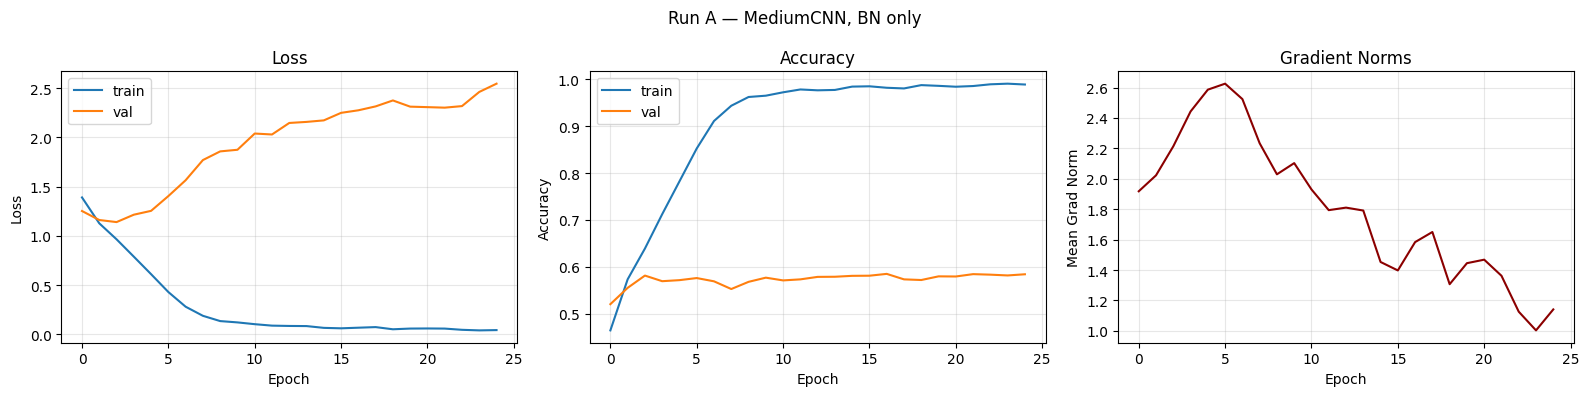

Best val acc: 0.5848
Final train acc: 0.9889, val acc: 0.5840
Train-Val gap: 0.4048


In [7]:
# Run A — BN only, no dropout, no L2
set_seed(42)
model_a = MediumCNN(dropout=0.0).to(device)
optimizer_a = optim.Adam(model_a.parameters(), lr=1e-3)

config_a = {
    'architecture': 'MediumCNN',
    'num_params': count_parameters(model_a),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'dropout': 0.0,
    'batch_norm': True,
    'batch_size': BATCH_SIZE,
    'num_epochs': 25,
    'regularization': 'BN only',
}

history_a, best_acc_a = train_model(
    model_a, train_loader, val_loader, optimizer_a, criterion, device,
    num_epochs=25, run_name='04_mediumcnn_bn_only',
    project=PROJECT, config=config_a,
    save_path=f'{PROJECT_DIR}/models/04_mediumcnn_bn_only.pt'
)
wandb.finish()
plot_training_curves(history_a, title="Run A — MediumCNN, BN only")
print(f"Best val acc: {best_acc_a:.4f}")
print(f"Final train acc: {history_a['train_acc'][-1]:.4f}, val acc: {history_a['val_acc'][-1]:.4f}")
print(f"Train-Val gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:.4f}")

## Run B — BN + Dropout 0.3

ვამატებთ moderate dropout-ს — ვნახოთ რამდენად ამცირებს overfit-ს.


Epoch   1/25 | train_loss 1.4163 acc 0.4533 | val_loss 1.2629 acc 0.5155 | grad 2.163 | lr 1.00e-03
Epoch   2/25 | train_loss 1.1687 acc 0.5590 | val_loss 1.2170 acc 0.5383 | grad 2.187 | lr 1.00e-03
Epoch   3/25 | train_loss 1.0349 acc 0.6134 | val_loss 1.1396 acc 0.5765 | grad 2.310 | lr 1.00e-03
Epoch   4/25 | train_loss 0.9045 acc 0.6655 | val_loss 1.1329 acc 0.5795 | grad 2.485 | lr 1.00e-03
Epoch   5/25 | train_loss 0.7772 acc 0.7137 | val_loss 1.1888 acc 0.5645 | grad 2.654 | lr 1.00e-03
Epoch   6/25 | train_loss 0.6364 acc 0.7668 | val_loss 1.2036 acc 0.5885 | grad 2.805 | lr 1.00e-03
Epoch   7/25 | train_loss 0.5073 acc 0.8168 | val_loss 1.2366 acc 0.5887 | grad 2.934 | lr 1.00e-03
Epoch   8/25 | train_loss 0.3900 acc 0.8618 | val_loss 1.5038 acc 0.5807 | grad 2.985 | lr 1.00e-03
Epoch   9/25 | train_loss 0.3039 acc 0.8966 | val_loss 1.5010 acc 0.5770 | grad 2.956 | lr 1.00e-03
Epoch  10/25 | train_loss 0.2547 acc 0.9130 | val_loss 1.6303 acc 0.5843 | grad 2.885 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
grad_norm,▂▂▃▅▆▇███▇▆▆▆▅▄▄▄▄▃▃▂▁▂▂▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▄▅▆▆▇▇▇██████████████
train_loss,█▇▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▇▇▆██▇▇▇▆▇▇▇▇▇▇█▇▇▇█▇█▇
val_loss,▂▁▁▁▁▁▂▃▃▄▅▄▅▅▆▆▆▆▆▇▇▇▇▇█
best_val_acc,0.58958
epoch,25
grad_norm,1.98162


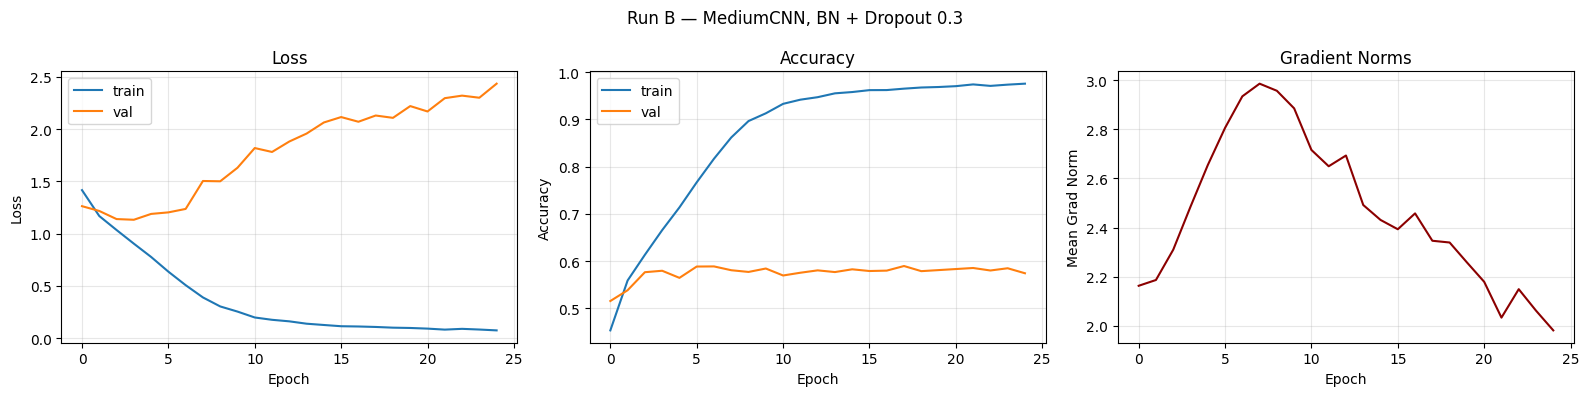

Best val acc: 0.5896
Final train acc: 0.9757, val acc: 0.5743
Train-Val gap: 0.4015


In [8]:
# Run B — BN + Dropout 0.3
set_seed(42)
model_b = MediumCNN(dropout=0.3).to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=1e-3)

config_b = {
    'architecture': 'MediumCNN',
    'num_params': count_parameters(model_b),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'dropout': 0.3,
    'batch_norm': True,
    'batch_size': BATCH_SIZE,
    'num_epochs': 25,
    'regularization': 'BN + Dropout 0.3',
}

history_b, best_acc_b = train_model(
    model_b, train_loader, val_loader, optimizer_b, criterion, device,
    num_epochs=25, run_name='04_mediumcnn_bn_drop03',
    project=PROJECT, config=config_b,
    save_path=f'{PROJECT_DIR}/models/04_mediumcnn_bn_drop03.pt'
)
wandb.finish()
plot_training_curves(history_b, title="Run B — MediumCNN, BN + Dropout 0.3")
print(f"Best val acc: {best_acc_b:.4f}")
print(f"Final train acc: {history_b['train_acc'][-1]:.4f}, val acc: {history_b['val_acc'][-1]:.4f}")
print(f"Train-Val gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:.4f}")

## Run C — BN + Dropout 0.5 + L2 + Cosine LR

მძლავრი regularization combo + LR scheduling. ეს უნდა იყოს ჯერჯერობით საუკეთესო configuration.


Epoch   1/30 | train_loss 1.4555 acc 0.4375 | val_loss 1.2654 acc 0.5099 | grad 2.405 | lr 1.00e-03
Epoch   2/30 | train_loss 1.2177 acc 0.5386 | val_loss 1.1883 acc 0.5397 | grad 2.288 | lr 9.97e-04
Epoch   3/30 | train_loss 1.1056 acc 0.5821 | val_loss 1.1638 acc 0.5587 | grad 2.375 | lr 9.89e-04
Epoch   4/30 | train_loss 1.0021 acc 0.6247 | val_loss 1.1191 acc 0.5801 | grad 2.505 | lr 9.76e-04
Epoch   5/30 | train_loss 0.9109 acc 0.6628 | val_loss 1.1430 acc 0.5804 | grad 2.650 | lr 9.57e-04
Epoch   6/30 | train_loss 0.8049 acc 0.7033 | val_loss 1.1576 acc 0.5801 | grad 2.777 | lr 9.33e-04
Epoch   7/30 | train_loss 0.6940 acc 0.7463 | val_loss 1.1703 acc 0.5871 | grad 2.996 | lr 9.05e-04
Epoch   8/30 | train_loss 0.5874 acc 0.7836 | val_loss 1.2269 acc 0.5798 | grad 3.152 | lr 8.72e-04
Epoch   9/30 | train_loss 0.4828 acc 0.8276 | val_loss 1.2817 acc 0.5865 | grad 3.252 | lr 8.35e-04
Epoch  10/30 | train_loss 0.4054 acc 0.8554 | val_loss 1.3848 acc 0.5860 | grad 3.359 | lr 7.94e-04


best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
grad_norm,▅▅▅▆▆▆▇▇████▇▇▇▆▆▅▅▄▄▃▂▂▂▂▁▁▁▁
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train_acc,▁▂▃▃▄▄▅▅▆▆▇▇▇▇▇███████████████
train_loss,█▇▆▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▇▇▇▇▇▇▇▇█▇▇▇▇▇██▇█▇████████
val_loss,▂▁▁▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇▇████████
best_val_acc,0.59766
epoch,30
grad_norm,0.92898


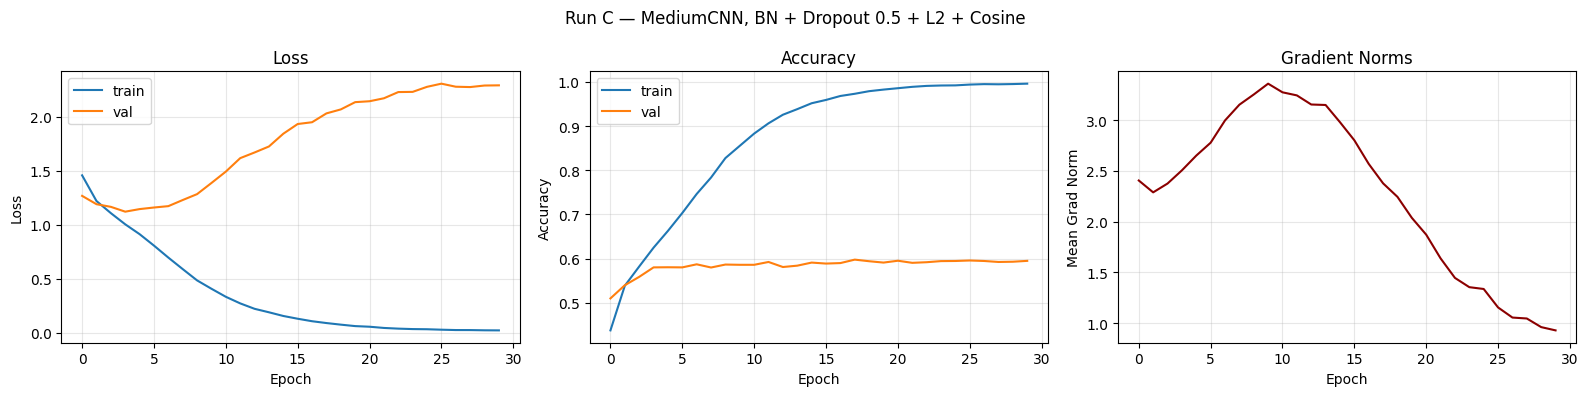

Best val acc: 0.5977
Final train acc: 0.9961, val acc: 0.5949
Train-Val gap: 0.4012


In [9]:
# Run C — full regularization combo
set_seed(42)
model_c = MediumCNN(dropout=0.5).to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=30)

config_c = {
    'architecture': 'MediumCNN',
    'num_params': count_parameters(model_c),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'dropout': 0.5,
    'batch_norm': True,
    'lr_scheduler': 'CosineAnnealingLR',
    'batch_size': BATCH_SIZE,
    'num_epochs': 30,
    'regularization': 'BN + Dropout 0.5 + L2 + CosineLR',
}

history_c, best_acc_c = train_model(
    model_c, train_loader, val_loader, optimizer_c, criterion, device,
    num_epochs=30, scheduler=scheduler_c,
    run_name='04_mediumcnn_bn_drop05_l2_cosine',
    project=PROJECT, config=config_c,
    save_path=f'{PROJECT_DIR}/models/04_mediumcnn_full.pt'
)
wandb.finish()
plot_training_curves(history_c, title="Run C — MediumCNN, BN + Dropout 0.5 + L2 + Cosine")
print(f"Best val acc: {best_acc_c:.4f}")
print(f"Final train acc: {history_c['train_acc'][-1]:.4f}, val acc: {history_c['val_acc'][-1]:.4f}")
print(f"Train-Val gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:.4f}")

## Run-ების შედარება

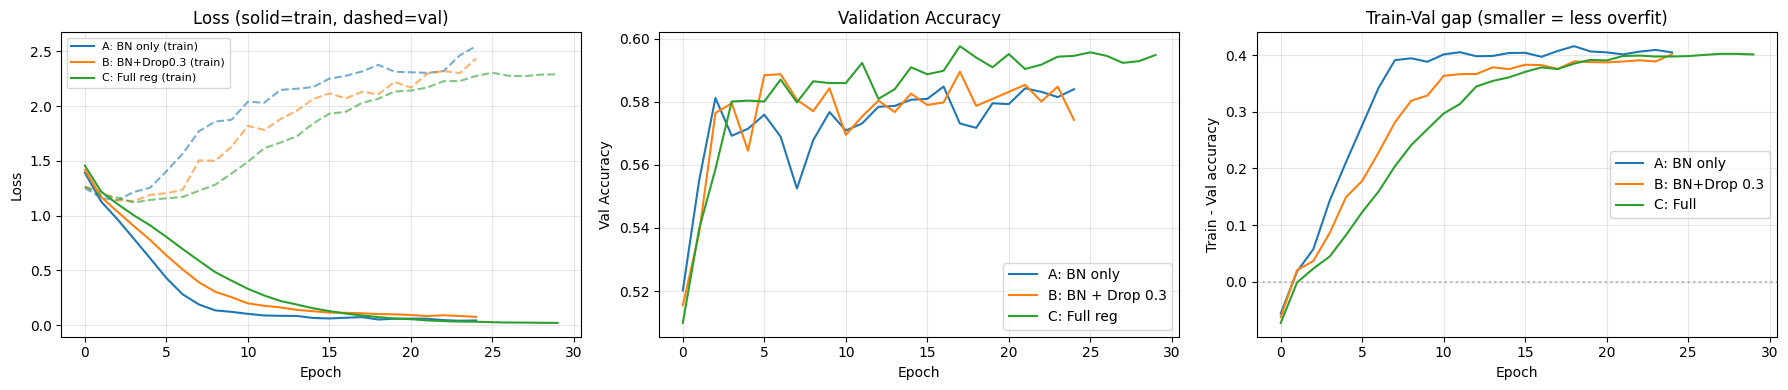


Final val accuracy comparison:
  Run A (BN only):              0.5848  [gap: +0.4048]
  Run B (BN + Drop 0.3):        0.5896  [gap: +0.4015]
  Run C (BN + Drop 0.5 + L2):   0.5977  [gap: +0.4012]


In [10]:
# შედარების plot-ი
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_a['train_loss'], label='A: BN only (train)', linestyle='-')
axes[0].plot(history_a['val_loss'], linestyle='--', alpha=0.6, color='C0')
axes[0].plot(history_b['train_loss'], label='B: BN+Drop0.3 (train)', linestyle='-')
axes[0].plot(history_b['val_loss'], linestyle='--', alpha=0.6, color='C1')
axes[0].plot(history_c['train_loss'], label='C: Full reg (train)', linestyle='-')
axes[0].plot(history_c['val_loss'], linestyle='--', alpha=0.6, color='C2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (solid=train, dashed=val)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_a['val_acc'], label='A: BN only')
axes[1].plot(history_b['val_acc'], label='B: BN + Drop 0.3')
axes[1].plot(history_c['val_acc'], label='C: Full reg')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Train-Val gap-ი ყველაზე საინტერესოა
for h, label in [(history_a, 'A: BN only'), (history_b, 'B: BN+Drop 0.3'), (history_c, 'C: Full')]:
    gaps = [t - v for t, v in zip(h['train_acc'], h['val_acc'])]
    axes[2].plot(gaps, label=label)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train - Val accuracy')
axes[2].set_title('Train-Val gap (smaller = less overfit)')
axes[2].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal val accuracy comparison:")
print(f"  Run A (BN only):              {best_acc_a:.4f}  [gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:+.4f}]")
print(f"  Run B (BN + Drop 0.3):        {best_acc_b:.4f}  [gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:+.4f}]")
print(f"  Run C (BN + Drop 0.5 + L2):   {best_acc_c:.4f}  [gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:+.4f}]")

## საუკეთესო Run-ის Test Evaluation

საუკეთესო Run: C (val_acc=0.5977)

Test loss: 1.9400
Test accuracy: 0.6069


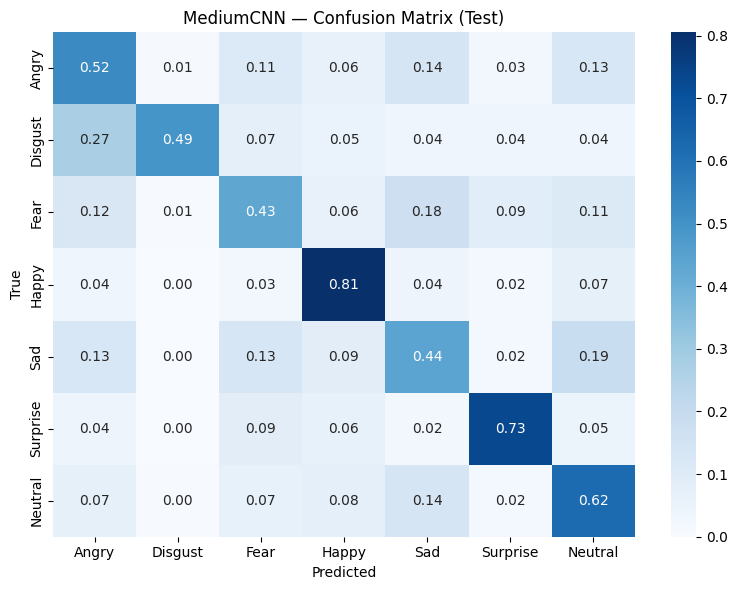

              precision    recall  f1-score   support

       Angry     0.5029    0.5234    0.5130       491
     Disgust     0.7105    0.4909    0.5806        55
        Fear     0.4882    0.4318    0.4583       528
       Happy     0.7849    0.8055    0.7951       879
         Sad     0.4705    0.4428    0.4562       594
    Surprise     0.7506    0.7308    0.7406       416
     Neutral     0.5530    0.6246    0.5866       626

    accuracy                         0.6069      3589
   macro avg     0.6087    0.5785    0.5901      3589
weighted avg     0.6051    0.6069    0.6049      3589



In [11]:
# საუკეთესოს არჩევა
best_runs = {
    'A': (best_acc_a, f'{PROJECT_DIR}/models/04_mediumcnn_bn_only.pt'),
    'B': (best_acc_b, f'{PROJECT_DIR}/models/04_mediumcnn_bn_drop03.pt'),
    'C': (best_acc_c, f'{PROJECT_DIR}/models/04_mediumcnn_full.pt'),
}
best_label = max(best_runs, key=lambda k: best_runs[k][0])
best_acc, best_path = best_runs[best_label]
print(f"საუკეთესო Run: {best_label} (val_acc={best_acc:.4f})")

# საუკეთესო model-ის ჩატვირთვა (კონფიგით)
if best_label == 'A':
    best_model = MediumCNN(dropout=0.0).to(device)
elif best_label == 'B':
    best_model = MediumCNN(dropout=0.3).to(device)
else:
    best_model = MediumCNN(dropout=0.5).to(device)

best_model.load_state_dict(torch.load(best_path))

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

preds, labels = get_predictions(best_model, test_loader, device)
_ = plot_confusion_matrix(preds, labels, title="MediumCNN — Confusion Matrix (Test)")
print_classification_report(preds, labels)

## ანალიზი

**შედეგები:**
- Run A (BN only): val 58.48%, gap 40.48%
- Run B (BN + Drop 0.3): val 58.96%, gap 40.15%
- Run C (BN + Drop 0.5 + L2 + Cosine): val 59.77%, **test 60.69%** — საუკეთესო

**მთავარი მიგნება (მოულოდნელი):**
- val_acc 57% → 60% (+3pp), test_acc 56% → **60.69%** (+4pp)
- მაგრამ **gap თითქმის არ შემცირდა** (~40% სამივე run-ში!)
- Train_acc 96% → 99.6% — BN-მა ოპტიმიზაცია გააძლიერა, model-ი ბევრად უკეთ memorize-ს

**რა მოხდა:**
- BN-მა გრადიენტები მოაშინიერა, training სტაბილური
- Dropout 0.3 / 0.5 თითქმის არ ცვლის gap-ს — capacity (1.27M params) regularization-ის ეფექტს აღემატება
- **დასკვნა:** model-ი ძალიან ძლიერია train data-სთვის — გვჭირდება **data augmentation** რომ train data variability გავზარდოთ

**per-class F1 progress (SmallCNN → MediumCNN):**
- Happy: 0.76 → 0.80
- Surprise: 0.69 → 0.74
- **Disgust: 0.47 → 0.58** (BN ეხმარება rare კლასს)
- Macro F1: 0.53 → 0.59

 შემდეგი: **05_vgg_style.ipynb** — VGG + Data Augmentation